## Importing Packages

In [2]:
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fastf1.plotting.setup_mpl()

## Loading Session Data

In [3]:
year = 2020
race = "Italian Grand Prix"

session = fastf1.get_session(year, race, 'R')
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (746.4 MB) C:\Users\odath\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Italian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 10 completed the race distance 00:00.067000 before the recorded end of the session.
core           INFO 	Finished 

## Loading and Preparing Lap Data

In [4]:
laps = session.laps
laps = laps.sort_values(['Driver', 'LapNumber'])
laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
742,0 days 00:35:03.148000,ALB,23,0 days 00:01:34.938000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.205000,...,Red Bull Racing,0 days 00:33:28.079000,2020-09-06 13:13:28.275,1,15.0,False,,False,False,94.938
743,0 days 00:36:31.456000,ALB,23,0 days 00:01:28.308000,2.0,1.0,NaT,NaT,0 days 00:00:28.516000,0 days 00:00:30.436000,...,Red Bull Racing,0 days 00:35:03.148000,2020-09-06 13:15:03.344,1,15.0,False,,False,True,88.308
744,0 days 00:37:58.420000,ALB,23,0 days 00:01:26.964000,3.0,1.0,NaT,NaT,0 days 00:00:28.146000,0 days 00:00:29.837000,...,Red Bull Racing,0 days 00:36:31.456000,2020-09-06 13:16:31.652,1,15.0,False,,False,True,86.964
745,0 days 00:39:24.892000,ALB,23,0 days 00:01:26.472000,4.0,1.0,NaT,NaT,0 days 00:00:28.039000,0 days 00:00:29.721000,...,Red Bull Racing,0 days 00:37:58.420000,2020-09-06 13:17:58.616,1,14.0,False,,False,True,86.472
746,0 days 00:40:51.051000,ALB,23,0 days 00:01:26.159000,5.0,1.0,NaT,NaT,0 days 00:00:27.968000,0 days 00:00:29.321000,...,Red Bull Racing,0 days 00:39:24.892000,2020-09-06 13:19:25.088,1,14.0,False,,False,True,86.159


## Compound color map

In [5]:
COMPOUND_COLORS = {
    'SOFT': '#FF3333',
    'MEDIUM': '#FFD700',
    'HARD': "#C6BFBF",
    'INTERMEDIATE': '#39B54A',
    'WET': '#0077FF'
}

## Race Statergy Comparison between different drivers

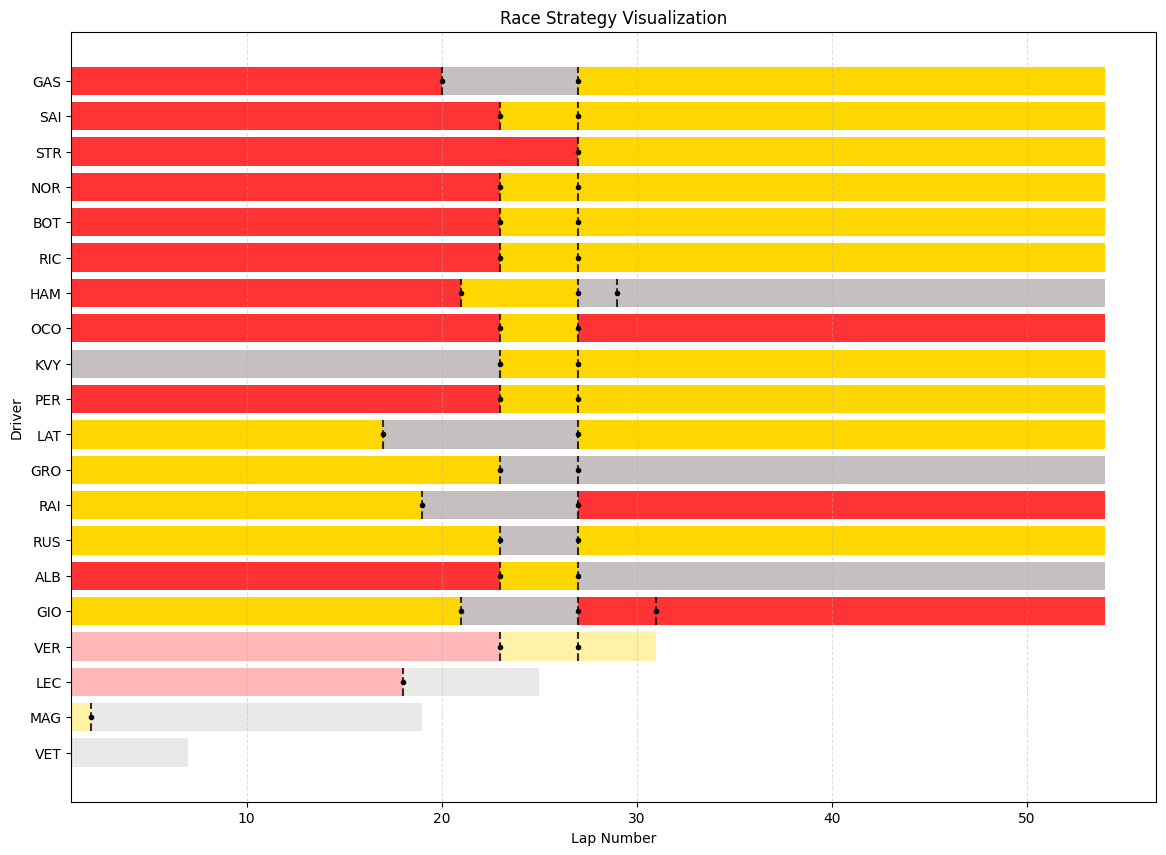

In [ ]:
# Get finishing order
finishing_order = session.results.sort_values('Position')['Abbreviation'].tolist()
drivers = finishing_order[::-1]  # P1 at bottom

results = session.results
dnf_drivers = session.results[
    (session.results['Position'].isna()) |
    (session.results['Status'].str.contains('Oil leak|Water pressure|Power Unit|Suspension|Brakes|Collision|Accident|Engine|Retired|Gearbox', na=False))
]['Abbreviation'].tolist()


y_positions = {driver: i for i, driver in enumerate(drivers)}

fig, ax = plt.subplots(figsize=(14,10))

for driver in drivers:
    driver_laps = laps[laps['Driver'] == driver]
    stints = driver_laps.groupby('Stint')

    alpha = 0.35 if driver in dnf_drivers else 1.0
    y = y_positions[driver]

    for stint, data in stints:
        compound = data['Compound'].mode()[0]
        width = data['LapNumber'].max() - data['LapNumber'].min() + 1

        ax.barh(
            y,
            width,
            left=data['LapNumber'].min(),
            color=COMPOUND_COLORS.get(compound, '#AAAAAA'),
            alpha=alpha
        )

    # Pit stop markers
    pit_laps = driver_laps.loc[
        driver_laps['Stint'].diff() == 1, 'LapNumber'
    ]

    for lap in pit_laps:
        ax.plot(lap, y, marker='o', color='black', markersize=3, zorder=6)
        ax.vlines(
            lap,
            y - 0.4,
            y + 0.4,
            colors='black',
            linestyles='dashed',
            linewidth=1.5,
            alpha=0.8,
            zorder=5
        )

# Fix y-axis labels
ax.set_yticks(range(len(drivers)))
ax.set_yticklabels(drivers)

ax.set_xlabel("Lap Number")
ax.set_ylabel("Driver")
ax.set_title("Race Strategy Visualization")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()